In [ ]:
import sys
import datetime as dt
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.resampled_data_loader import get_resampled_quotes

instruments = ['USDSGD', 'EURUSD', 'AUDUSD', 'GBPUSD', 'USDJPY', 'USDHKD']
ccys = ['USD', 'EUR', 'AUD', 'GBP', 'JPY', 'HKD']

start_date = dt.datetime(2025, 1, 1)
end_date = dt.datetime(2025, 12, 31)
freq = pd.Timedelta(minutes=15)

prices = get_resampled_quotes(instruments, start_date, end_date, freq)

In [79]:
def regression_stats(x, y):
    sample = pd.concat({"x": x, "y": y}, axis=1).dropna()
    if len(sample) < 3 or sample["x"].var() == 0 or sample["y"].var() == 0:
        return np.nan, np.nan, len(sample)

    beta = sample["y"].cov(sample["x"]) / sample["x"].var()
    corr = sample["x"].corr(sample["y"])
    return beta, corr, len(sample)

In [55]:
import importlib
import strategy.sgd_neer_strategy as sn

importlib.reload(sn)
from strategy.sgd_neer_strategy import SGDNEERStrategy

strategy = SGDNEERStrategy(instruments, prices,
                        {
                            "rolling_window" : pd.Timedelta(minutes=15),
                            "zscore_window" : pd.Timedelta(minutes=1200),
                            "zscore_threshold" : 1.5,
                        })


In [56]:
signals = strategy.generate_signals()


In [61]:
ccy_signals = strategy._currency_signals(strategy.build_rets_vs_sgd())
pd.DataFrame(ccy_signals)

,USD,EUR,JPY,AUD,GBP,HKD
timestamp,,,,,,
2025-01-01 18:00:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 18:15:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 18:30:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 18:45:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 19:00:00-05:00,0.0,1.0,-1.0,0.0,1.0,0.0
...,...,...,...,...,...,...
2025-12-31 15:45:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31 16:00:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31 16:15:00-05:00,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(instruments, prices, signals)

report = PerformanceReport(instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
USDSGD,-16.027382,-0.49016,28.436813,-1.398904,-0.026721,-0.000135,-0.000002,0 days 00:18:59.582297,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00
EURUSD,-1.929164,1.015759,13.43956,-0.120044,-0.008353,-0.000018,0.000009,0 days 00:20:11.446921,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00
AUDUSD,-7.907007,0.648907,12.538462,-0.4176,-0.015727,-0.000091,0.000007,0 days 00:16:43.345724,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
GBPUSD,-4.665521,0.647721,13.972527,-0.20492,-0.008013,-0.000039,0.000005,0 days 00:17:11.039478,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00
USDJPY,-2.906222,-0.543749,12.337912,-0.147703,-0.010386,-0.000032,-0.000006,0 days 00:17:56.589473,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
USDHKD,-15.885744,-1.586657,13.197802,-0.116405,-0.001754,-0.000024,-0.000001,0 days 00:17:50.677570,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00


<Axes: title={'center': 'GBPUSD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

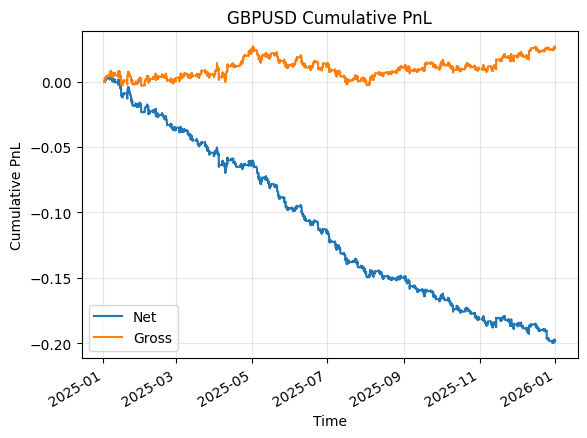

In [65]:
report.plot_cumulative_pnl('GBPUSD')

In [77]:
rets_vs_sgd = strategy.build_rets_vs_sgd()

In [ ]:
rolling_windows_mins = [15, 30, 60, 120]
fwd_periods_mins = [15, 30, 60]

zscore_window_mins = 120

bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = [x // bar_minutes for x in rolling_windows_mins]
fwd_periods = [x // bar_minutes for x in fwd_periods_mins]
zscore_window = zscore_window_mins // bar_minutes

zscore_bins = [
    (0, 0.5),
    (0.5, 1),
    (1, 2),
    (2, np.inf),
]

results = []

for rolling_window_mins, rolling_window in zip(rolling_windows_mins, rolling_windows):
    for fwd_period_mins, fwd_period in zip(fwd_periods_mins, fwd_periods):
        for ccy in ccys + ["index"]:
            if ccy == "index":
                past_ret = rets_vs_sgd["index"].rolling(rolling_window).sum()
            else:
                past_ret = (
                    rets_vs_sgd[ccy] - rets_vs_sgd["index"]
                ).rolling(rolling_window).sum()

            past_z = (
                (past_ret - past_ret.rolling(zscore_window).mean())
                / past_ret.rolling(zscore_window).std()
            )

            future_ccy_ret = (
                rets_vs_sgd[ccy]
                .rolling(fwd_period)
                .sum()
                .shift(-fwd_period)
            )

            abs_z = past_z.abs()

            for lower, upper in zscore_bins:
                if np.isinf(upper):
                    bucket_mask = abs_z > lower
                    z_bucket = f">{lower}"
                else:
                    bucket_mask = (abs_z >= lower) & (abs_z < upper)
                    z_bucket = f"{lower}-{upper}"

                beta, corr, n_obs = regression_stats(
                    past_z[bucket_mask],
                    future_ccy_ret[bucket_mask],
                )

                results.append({
                    "ccy": ccy,
                    "rolling_window_mins": rolling_window_mins,
                    "fwd_period_mins": fwd_period_mins,
                    "zscore_window_mins": zscore_window_mins,
                    "z_bucket": z_bucket,
                    "beta": beta,
                    "corr": corr,
                    "n_obs": n_obs,
                })

zscore_bucket_results = pd.DataFrame(results)

zscore_bucket_results.sort_values(
    ["rolling_window_mins", "fwd_period_mins", "ccy", "z_bucket"]
)


,ccy,rolling_window_mins,fwd_period_mins,zscore_window_mins,z_bucket,beta,corr,n_obs
8,AUD,15,15,120,0-0.5,-1.320764e-05,-0.007810,9715
9,AUD,15,15,120,0.5-1,1.348920e-05,0.021846,7285
10,AUD,15,15,120,1-2,-2.307882e-06,-0.006397,6976
11,AUD,15,15,120,>2,-9.211612e-07,-0.002953,647
4,EUR,15,15,120,0-0.5,-8.568399e-06,-0.007327,9611
...,...,...,...,...,...,...,...,...
311,USD,120,60,120,>2,1.199804e-06,0.003590,895
332,index,120,60,120,0-0.5,-1.101756e-05,-0.010205,6292
333,index,120,60,120,0.5-1,-1.005543e-05,-0.024727,6798
334,index,120,60,120,1-2,-2.070822e-05,-0.088374,10619


In [75]:
zscore_bucket_results.pivot_table(
    index=["rolling_window_mins", "fwd_period_mins", "ccy"],
    columns="z_bucket",
    values="corr",
).to_clipboard()


In [78]:
rets_vs_sgd.columns.to_list()

['index', 'USD', 'EUR', 'JPY', 'AUD', 'GBP', 'HKD']

<Axes: xlabel='timestamp'>

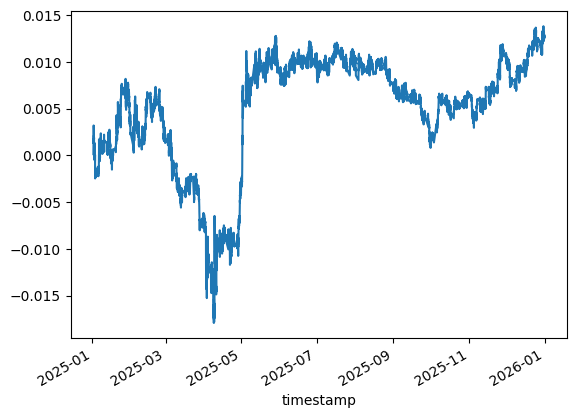

In [ ]:
rets['index'].cumsum().plot()

<Axes: xlabel='timestamp'>

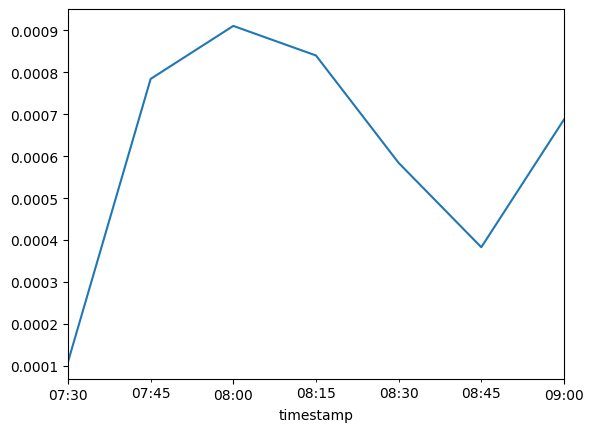

In [13]:
rets.loc['2025-07-03 07:30' : '2025-07-03 09:00']['index'].cumsum().plot()

In [ ]:
rolling_windows_mins = 15
fwd_periods_mins = 15
zscore_window_mins = 120
bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = rolling_windows_mins // bar_minutes
fwd_periods = fwd_periods_mins // bar_minutes
zscore_window = zscore_window_mins // bar_minutes

results = rets_vs_sgd.copy()

for ccy in ccys + ["index"]:

    past_ret = rets_vs_sgd[ccy].rolling(rolling_window).sum()
    past_relative_ret = (rets_vs_sgd[ccy] - rets_vs_sgd["index"]).rolling(rolling_window).sum()

    past_z = (
        (past_ret - past_ret.rolling(zscore_window).mean())
        / past_ret.rolling(zscore_window).std()
    )

    past_relative_z = (
        (past_relative_ret - past_relative_ret.rolling(zscore_window).mean())
        / past_relative_ret.rolling(zscore_window).std()
    )

    future_ccy_ret = (
        rets_vs_sgd[ccy]
        .rolling(fwd_period)
        .sum()
        .shift(-fwd_period)
    )

    results[ccy + "_past_ret"] = past_ret
    results[ccy + "_past_z"] = past_z
    results[ccy + "_past_relative_ret"] = past_relative_ret
    results[ccy + "_past_relative_z"] = past_relative_z

In [89]:
results

,index,USD,EUR,JPY,AUD,GBP,HKD,USDpast_ret,USDpast_z,USDpast_relative_ret,...,JPYpast_relative_ret,JPYpast_relative_z,HKDpast_ret,HKDpast_z,HKDpast_relative_ret,HKDpast_relative_z,indexpast_ret,indexpast_z,indexpast_relative_ret,indexpast_relative_z
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 18:00:00-05:00,0.000141,1.171234e-04,0.000190,0.000187,0.000061,0.000157,0.000037,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 18:15:00-05:00,0.000263,2.635779e-04,0.000534,0.000162,-0.000237,0.000308,0.000284,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 18:30:00-05:00,0.000087,-6.590099e-05,0.000156,0.000363,0.000071,-0.000086,-0.000038,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 18:45:00-05:00,-0.000023,-1.830355e-04,0.000034,0.000557,-0.000441,-0.000103,-0.000193,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 19:00:00-05:00,0.000583,3.990606e-04,0.000244,0.002030,0.000084,-0.000100,0.000353,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 15:45:00-05:00,0.000116,1.905825e-04,0.000110,0.000120,-0.000064,-0.000091,0.000191,0.000937,1.649006,0.000662,...,-0.000748,-1.447249,0.000840,1.795807,0.000565,1.806472,0.000275,1.538920,0.0,NaN
2025-12-31 16:00:00-05:00,-0.000125,-1.665335e-16,-0.000315,-0.000233,0.000090,-0.000271,0.000031,0.000906,1.295043,0.000762,...,-0.000875,-1.350563,0.000839,1.401781,0.000695,1.707093,0.000144,0.643696,0.0,NaN
2025-12-31 16:15:00-05:00,0.000165,3.889817e-06,0.000370,0.000301,0.000026,0.000171,0.000014,0.000618,0.258925,0.000357,...,-0.000562,-0.473798,0.000623,0.579518,0.000362,0.098322,0.000261,1.144070,0.0,NaN
